In [12]:
from nemo_curator.pipeline import Pipeline
from nemo_curator.stages.file_partitioning import FilePartitioningStage
from nemo_curator.stages.text.io.reader import JsonlReader
from nemo_curator.backends.xenna.executor import XennaExecutor
from nemo_curator.stages.text.modules import Score
from nemo_curator.stages.text.filters import (
    WordCountFilter,
    NumbersFilter,
    SymbolsToWordsFilter,
    UrlsFilter,
    RepeatingTopNGramsFilter,
    WhiteSpaceFilter,
    ParenthesesFilter,
    BoilerPlateStringFilter,
    RepeatedLinesFilter,
    RepeatedParagraphsFilter,
    RepeatedLinesByCharFilter,
    RepeatedParagraphsByCharFilter
)

pipeline = Pipeline(name="jsonl_data_processing")

pipeline.add_stage(
    JsonlReader(
        file_paths=["OCR/*/*.jsonl"],
        fields=["text", "id"]
    )
)


filters = [
    (WordCountFilter(), "word_count"),
    (NumbersFilter(), "numbers"),
    (SymbolsToWordsFilter(), "symbols_to_words"),
    (UrlsFilter(), "urls"),
    (RepeatingTopNGramsFilter(n=2), "repeating_2grams"),
    (RepeatingTopNGramsFilter(n=3), "repeating_3grams"),
    (WhiteSpaceFilter(), "whitespace"),
    (ParenthesesFilter(), "parentheses"),
    (BoilerPlateStringFilter(), "boilerplate_strings"),
    (RepeatedLinesFilter(), "repeated_lines"),
    (RepeatedParagraphsFilter(), "repeated_paragraphs"),
    (RepeatedLinesByCharFilter(), "repeated_lines_by_char"),
    (RepeatedParagraphsByCharFilter(), "repeated_paragraphs_by_char")
]

for flt, score_name in filters:
    pipeline.add_stage(
        Score(
            flt.score_document,
            score_field=score_name
        )
    )


results = pipeline.run()



2025-11-30 09:51:52.788 | INFO     | nemo_curator.pipeline.pipeline:add_stage:61 - Added stage 'jsonl_reader' to pipeline 'jsonl_data_processing'
2025-11-30 09:51:52.789 | INFO     | nemo_curator.pipeline.pipeline:add_stage:61 - Added stage 'score_fn' to pipeline 'jsonl_data_processing'
2025-11-30 09:51:52.789 | INFO     | nemo_curator.pipeline.pipeline:add_stage:61 - Added stage 'score_fn' to pipeline 'jsonl_data_processing'
2025-11-30 09:51:52.790 | INFO     | nemo_curator.pipeline.pipeline:add_stage:61 - Added stage 'score_fn' to pipeline 'jsonl_data_processing'
2025-11-30 09:51:52.790 | INFO     | nemo_curator.pipeline.pipeline:add_stage:61 - Added stage 'score_fn' to pipeline 'jsonl_data_processing'
2025-11-30 09:51:52.790 | INFO     | nemo_curator.pipeline.pipeline:add_stage:61 - Added stage 'score_fn' to pipeline 'jsonl_data_processing'
2025-11-30 09:51:52.791 | INFO     | nemo_curator.pipeline.pipeline:add_stage:61 - Added stage 'score_fn' to pipeline 'jsonl_data_processing'
20

In [34]:
import pandas as pd

dfs = []

score_fields = [score_name for _, score_name in filters]
keep = ["id"]+score_fields
for i in range(len(results)):
    dfs.append(results[i].data[keep])
all_results = pd.concat(dfs, ignore_index=True)
print(all_results.head())
#all_results.to_parquet("OCR_scores.parquet", index=False)

       id  word_count   numbers  symbols_to_words      urls  repeating_2grams  \
0  143332       30400  0.032368          0.000230  0.010902          0.000000   
1  145516       13272  0.016230          0.000075  0.009161          0.000000   
2  141599       19652  0.030614          0.000153  0.000000          0.000163   
3  142436        8486  0.026666          0.000471  0.016913          0.001425   
4  145925       25589  0.034753          0.000039  0.000565          0.000000   

   repeating_3grams  whitespace  parentheses  boilerplate_strings  \
0          0.004465    0.195979     0.003789                  0.0   
1          0.000000    0.161643     0.002038                  0.0   
2          0.000078    0.203492     0.003433                  0.0   
3          0.000913    0.172472     0.004073                  0.0   
4          0.000066    0.286963     0.003041                  0.0   

   repeated_lines  repeated_paragraphs  repeated_lines_by_char  \
0        0.945918             0.


Gigafida — word_count percentiles:
  P1   = 65.0
  P50  = 4378.0
  P99  = 191019.84999999963

Trendi — word_count percentiles:
  P1   = 63.0
  P50  = 250.0
  P99  = 1583.0


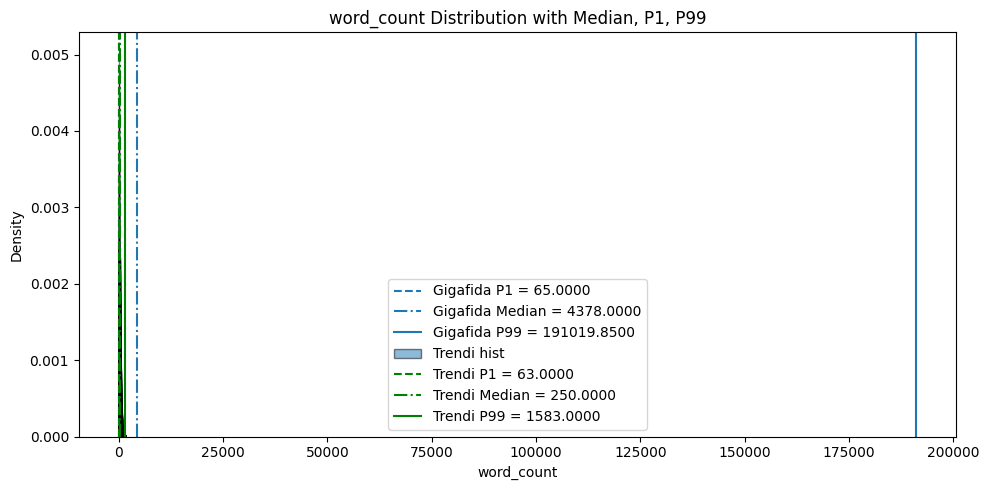


Gigafida — numbers percentiles:
  P1   = 0.0
  P50  = 0.007010415283352304
  P99  = 0.05915785802689255

Trendi — numbers percentiles:
  P1   = 0.0
  P50  = 0.006535947712418301
  P99  = 0.07393811391279762


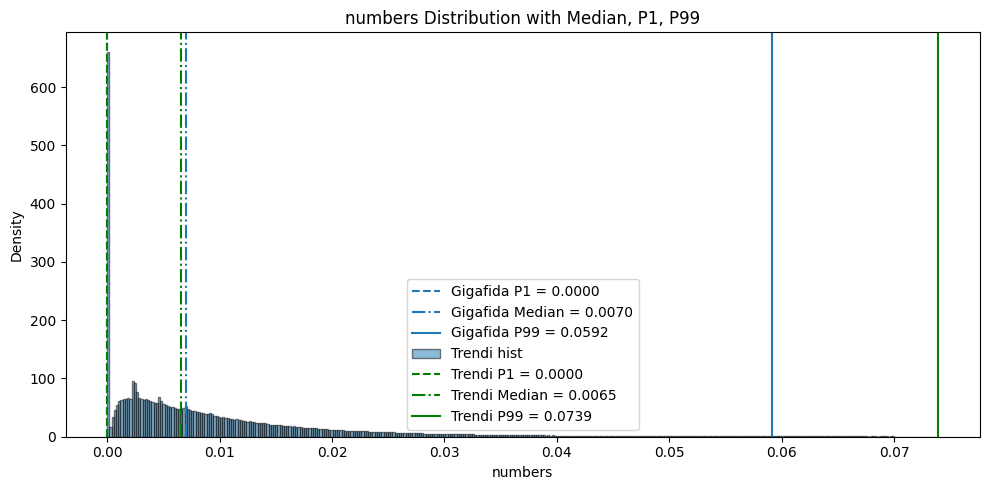


Gigafida — symbols_to_words percentiles:
  P1   = 0.0
  P50  = 0.0
  P99  = 0.010592963168060037

Trendi — symbols_to_words percentiles:
  P1   = 0.0
  P50  = 0.0
  P99  = 0.007575757575757576


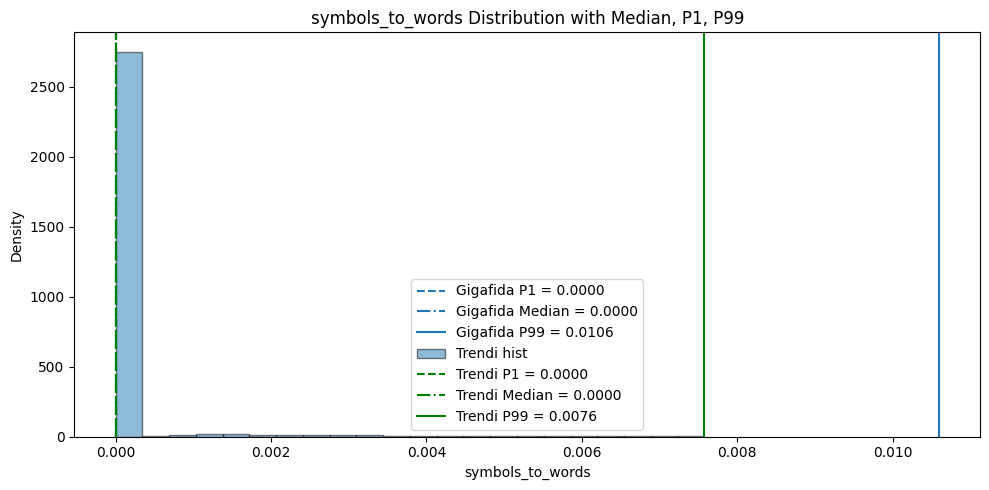


Gigafida — urls percentiles:
  P1   = 0.0
  P50  = 0.0
  P99  = 0.0021723931689407693

Trendi — urls percentiles:
  P1   = 0.0
  P50  = 0.0
  P99  = 0.0


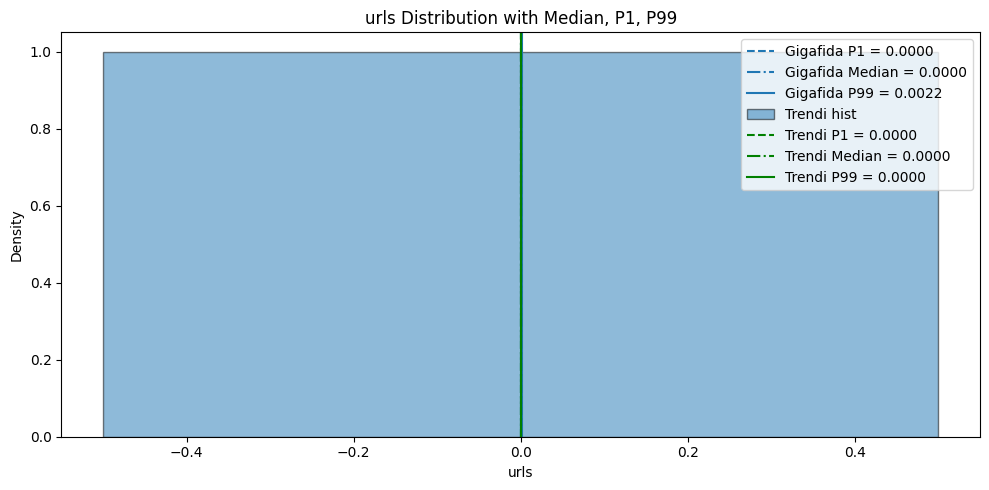


Gigafida — repeating_2grams percentiles:
  P1   = 0.0014543394225382206
  P50  = 0.0033605938185104806
  P99  = 0.05604478757505976

Trendi — repeating_2grams percentiles:
  P1   = 0.003317553889151676
  P50  = 0.014249525015832806
  P99  = 0.06842923794712286


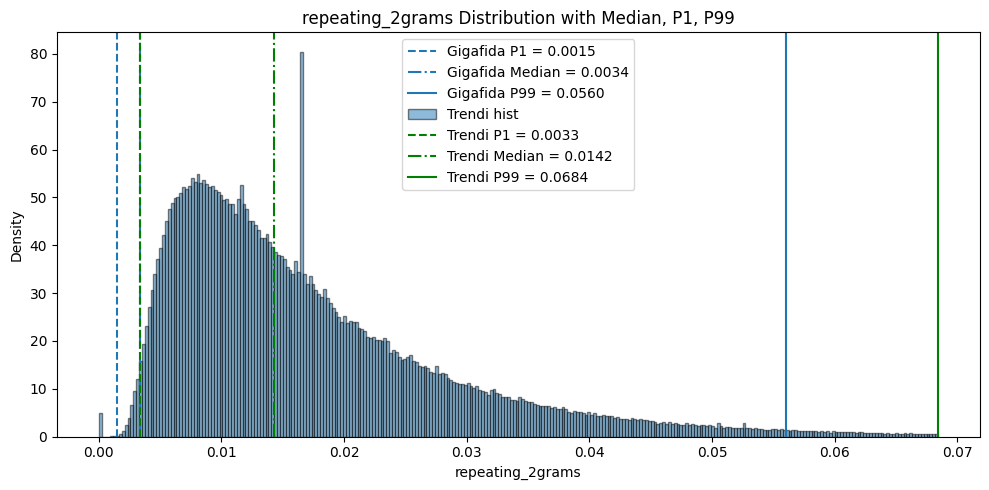


Gigafida — repeating_3grams percentiles:
  P1   = 0.00029395826730478923
  P50  = 0.0020684833724479382
  P99  = 0.06426394474558485

Trendi — repeating_3grams percentiles:
  P1   = 0.0
  P50  = 0.016917293233082706
  P99  = 0.07407407407407407


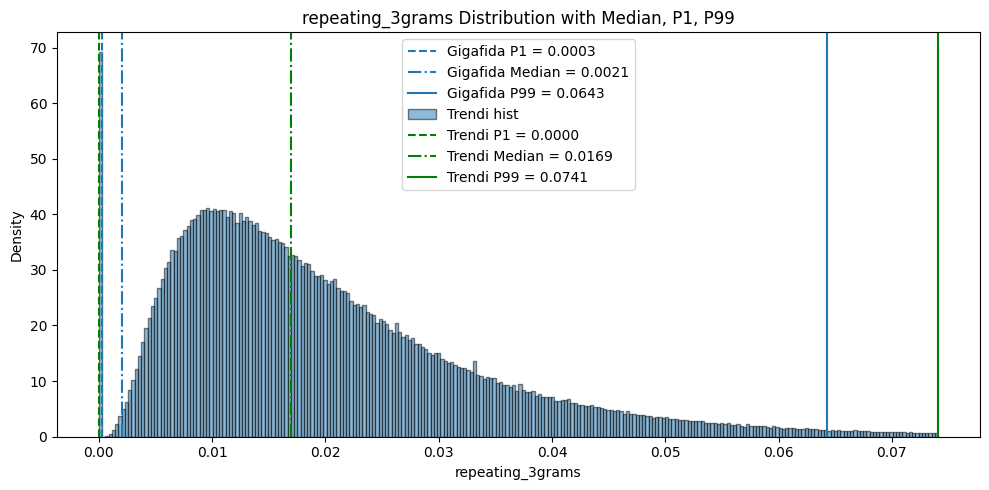


Gigafida — whitespace percentiles:
  P1   = 0.13781722624256232
  P50  = 0.15605535333002768
  P99  = 0.17716246169290675

Trendi — whitespace percentiles:
  P1   = 0.13424275611765965
  P50  = 0.155955441302485
  P99  = 0.18023887079261672


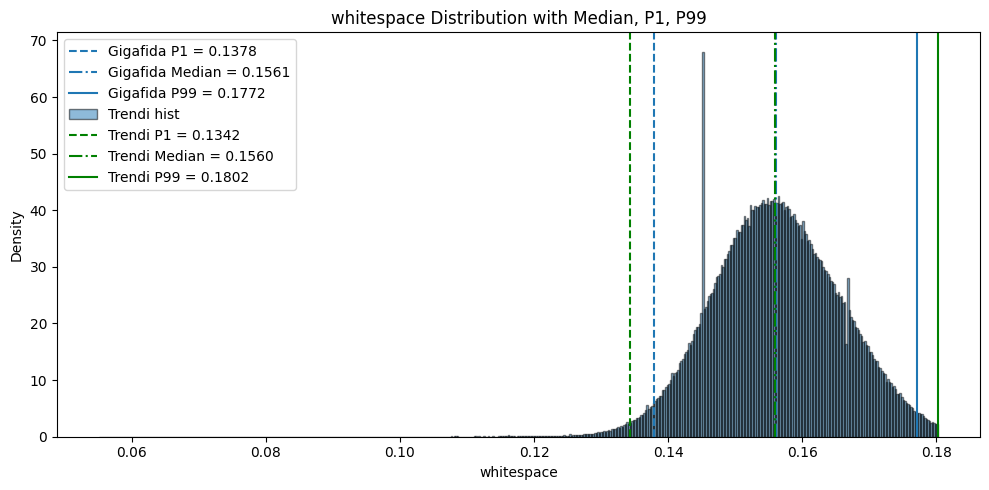


Gigafida — parentheses percentiles:
  P1   = 0.0
  P50  = 0.0014212860805825314
  P99  = 0.011949813215284277

Trendi — parentheses percentiles:
  P1   = 0.0
  P50  = 0.0005945303210463733
  P99  = 0.01486988847583643


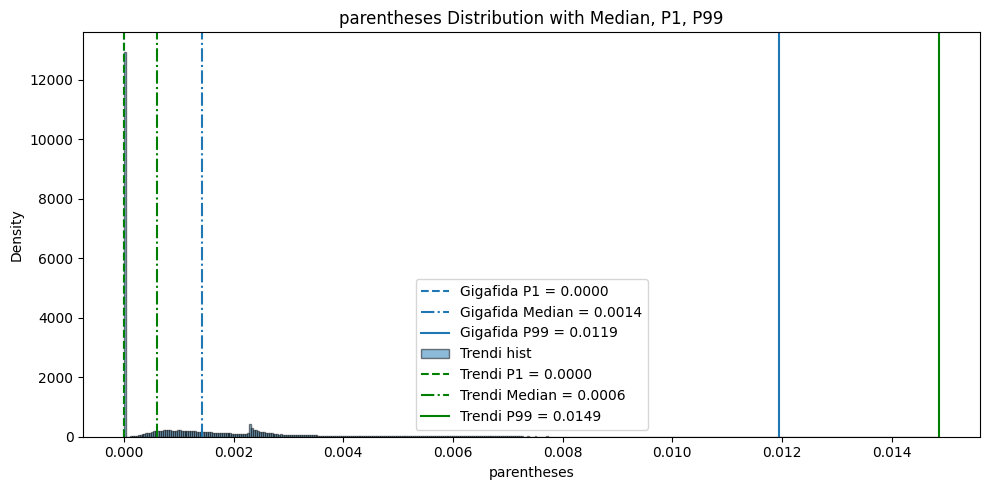


Gigafida — boilerplate_strings percentiles:
  P1   = 0.0
  P50  = 0.0
  P99  = 0.0

Trendi — boilerplate_strings percentiles:
  P1   = 0.0
  P50  = 0.0
  P99  = 0.0


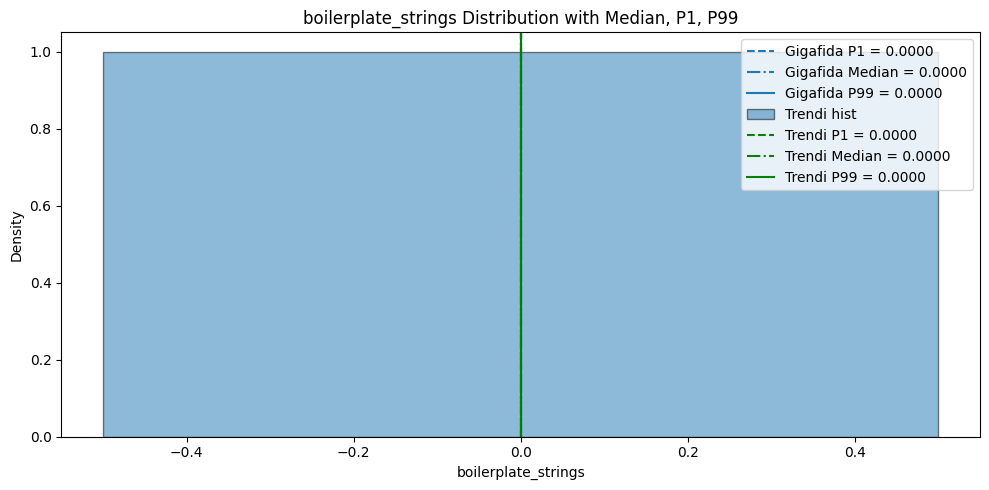


Gigafida — repeated_lines percentiles:
  P1   = 1.0
  P50  = 1.0
  P99  = 1.0

Trendi — repeated_lines percentiles:
  P1   = 1.0
  P50  = 1.0
  P99  = 1.0


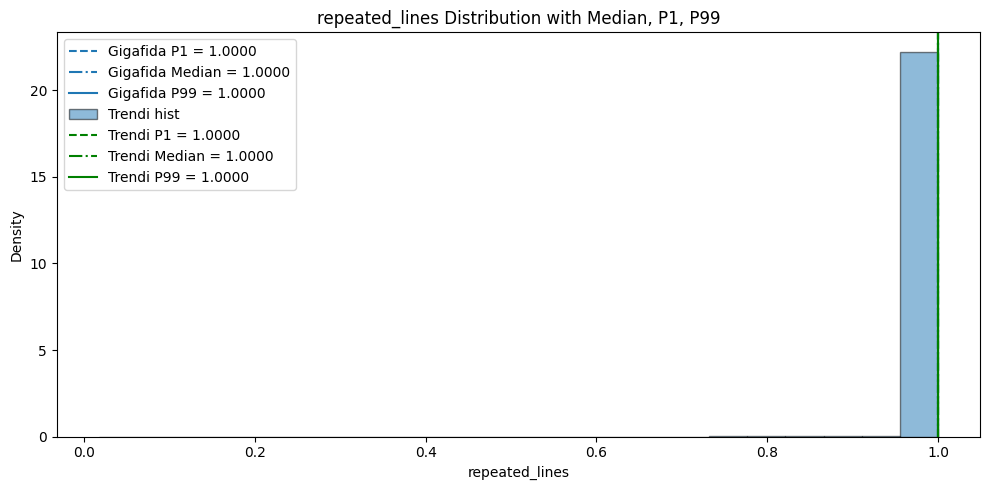


Gigafida — repeated_paragraphs percentiles:
  P1   = 1.0
  P50  = 1.0
  P99  = 1.0

Trendi — repeated_paragraphs percentiles:
  P1   = 1.0
  P50  = 1.0
  P99  = 1.0


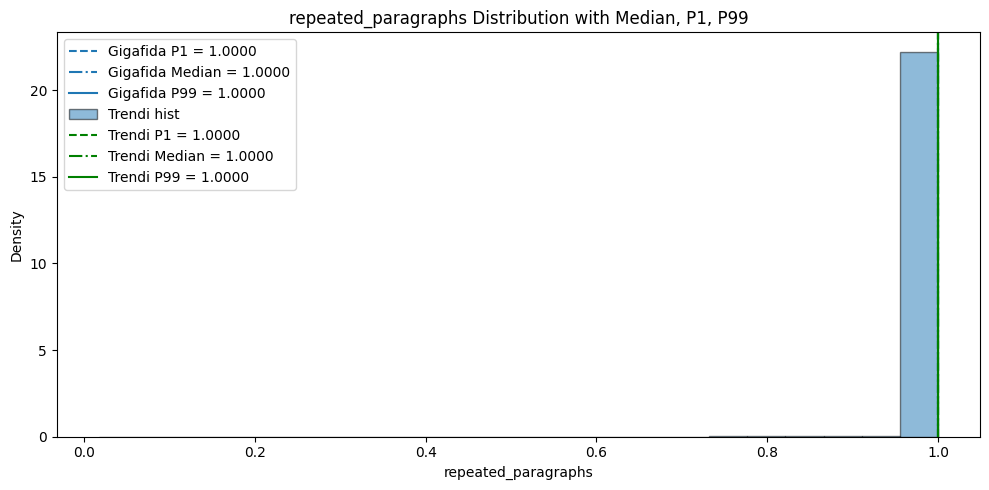


Gigafida — repeated_lines_by_char percentiles:
  P1   = 1.0
  P50  = 1.0
  P99  = 1.0

Trendi — repeated_lines_by_char percentiles:
  P1   = 1.0
  P50  = 1.0
  P99  = 1.0


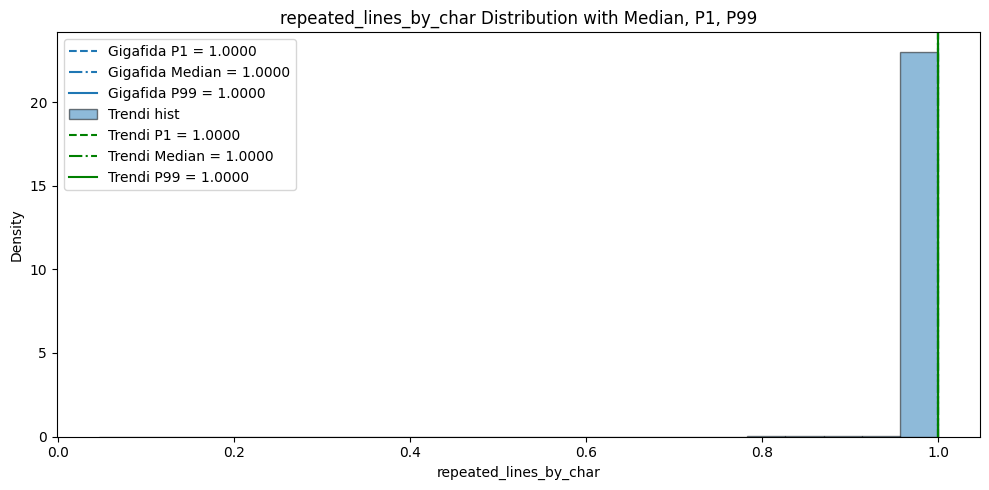


Gigafida — repeated_paragraphs_by_char percentiles:
  P1   = 1.0
  P50  = 1.0
  P99  = 1.0

Trendi — repeated_paragraphs_by_char percentiles:
  P1   = 1.0
  P50  = 1.0
  P99  = 1.0


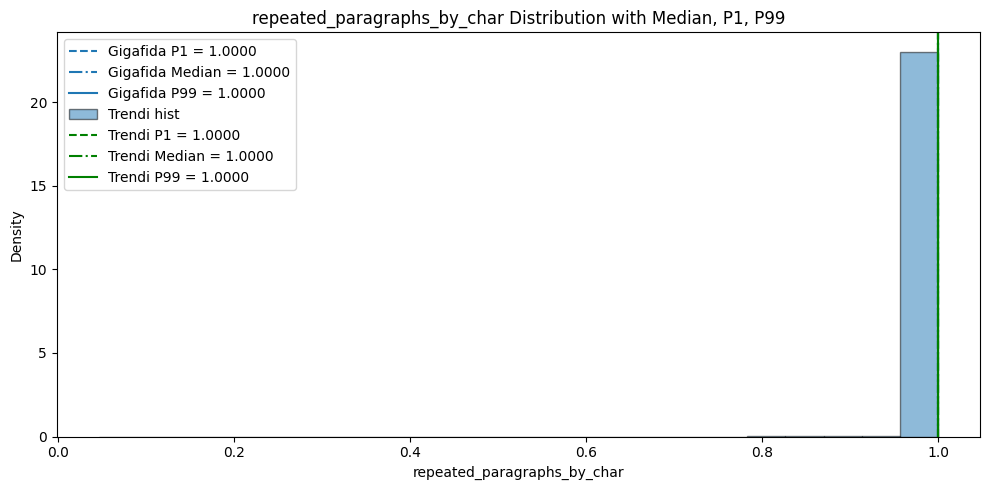

In [33]:
#Plot histograms with statistics
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

score_fields = [
    "word_count",
    "numbers",
    "symbols_to_words",
    "urls",
    "repeating_2grams",
    "repeating_3grams",
    "whitespace",
    "parentheses",
    "boilerplate_strings",
    "repeated_lines",
    "repeated_paragraphs",
    "repeated_lines_by_char",
    "repeated_paragraphs_by_char"
]


def get_percentiles(values):
    values = values.dropna()
    p1 = np.percentile(values, 1)
    p50 = np.percentile(values, 50)
    p99 = np.percentile(values, 99)
    return p1, p50, p99

def plot_single_hist(df, column, label, color=None, clip_outliers=True):
    values = df[column].dropna()
    p1, p50, p99 = get_percentiles(values)

    # Print percentiles
    print(f"\n{label} — {column} percentiles:")
    print(f"  P1   = {p1}")
    print(f"  P50  = {p50}")
    print(f"  P99  = {p99}")

    # Clip to P99 range for plotting
    if clip_outliers:
        values_plot = values[(values <= p99)]
    else:
        values_plot = values

    # Histogram
    plt.hist(
        values_plot,
        bins="auto",
        density=True,
        alpha=0.5,
        edgecolor="black",
        label=f"{label} hist",
    )

    # Percentile lines
    plt.axvline(p1,  linestyle="--", color=color, label=f"{label} P1 = {p1:.4f}")
    plt.axvline(p50, linestyle="-.", color=color, label=f"{label} Median = {p50:.4f}")
    plt.axvline(p99, linestyle="-",  color=color, label=f"{label} P99 = {p99:.4f}")

    return p1, p50, p99

def plot_with_percentiles(df1, column, df2=None, labels=("DF1", "DF2"), clip_outliers=True):
    """ Plot a gold reference histogram next to current text """
    plt.figure(figsize=(10, 5))

    values1 = df1[column].dropna()
    p1_1, p50_1, p99_1 = get_percentiles(values1)

    print(f"\n{labels[0]} — {column} percentiles:")
    print(f"  P1   = {p1_1}")
    print(f"  P50  = {p50_1}")
    print(f"  P99  = {p99_1}")

    # DF1 percentile lines only
    plt.axvline(p1_1,  linestyle="--", label=f"{labels[0]} P1 = {p1_1:.4f}")
    plt.axvline(p50_1, linestyle="-.", label=f"{labels[0]} Median = {p50_1:.4f}")
    plt.axvline(p99_1, linestyle="-", label=f"{labels[0]} P99 = {p99_1:.4f}")

    if df2 is not None:
        plot_single_hist(df2, column, labels[1], color="green", clip_outliers=clip_outliers)

    else:
        plot_single_hist(df1, column, labels[0], color=None, clip_outliers=clip_outliers)

    plt.title(f"{column} Distribution with Median, P1, P99")
    plt.xlabel(column)
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()

scores_trendi = pd.read_parquet("trendi.parquet")
scores_gig = pd.read_parquet("gigafida_scores.parquet")
#scores_ocr = pd.read_parquet("OCR_scores.parquet")
for col in score_fields:
    plot_with_percentiles(scores_gig, col, scores_trendi, ("Gigafida", "Trendi"))


In [38]:
#### MAD based filtering (Gigafida as a reference)

gig = pd.read_parquet("gigafida_scores.parquet")
trendi = pd.read_parquet("trendi.parquet")
ocr = pd.read_parquet("OCR_scores.parquet")

exclude = {"id"}
features = [c for c in gig.columns if c not in exclude]

# --- MAD stats --- #
mad_stats = {}
for f in features:
    median = gig[f].median()
    mad = abs((gig[f] - median)).median()
    mad_stats[f] = (median, mad)

def mad_z(x, median, mad):
    if mad == 0:
        return np.zeros_like(x, dtype=float)
    return np.abs(x - median) / mad

# --- Apply MAD-Z to any df using Gigafida stats --- #
def add_mad_features(df):
    for f in features:
        median, mad = mad_stats[f]
        df[f + "_madz"] = mad_z(df[f], median, mad)
    df["sum_madz"] = df[[f + "_madz" for f in features]].sum(axis=1)

add_mad_features(gig)
add_mad_features(trendi)
add_mad_features(ocr)

# --- Derive thresholds from Gigafida --- #
sum_thresh = gig["sum_madz"].quantile(0.99) 
feature_thresholds = {
    f: gig[f + "_madz"].quantile(0.99)
    for f in features
}

# --- Filter based on Gigafida --- #

trendi_sum_anomalies = trendi[trendi["sum_madz"] >= sum_thresh]


print(len(trendi))
print(len(trendi_sum_anomalies))
print("gig_sum_thresh: " + str(sum_thresh))
print(feature_thresholds)
symbols_anomalies = trendi[trendi["symbols_to_words_madz"] > 0]
print(len(symbols_anomalies))

1461815
9223
gig_sum_thresh: 139.8951014698721
{'word_count': 45.24650909090901, 'numbers': 15.28806649708151, 'symbols_to_words': 0.0, 'urls': 0.0, 'repeating_2grams': 49.403215023776745, 'repeating_3grams': 39.34863026465311, 'whitespace': 6.493876853471836, 'parentheses': 14.509527550965574, 'boilerplate_strings': 0.0, 'repeated_lines': 0.0, 'repeated_paragraphs': 0.0, 'repeated_lines_by_char': 0.0, 'repeated_paragraphs_by_char': 0.0}
0


In [31]:
#Find original text by id and save to file for manual inspection, ordered by the severity of the anmoaly
import glob
import json
import os
import re

def export_feature_anomalies_jsonl(df, feature_thresholds, jsonl_pattern, out_prefix, id_col="id"):
    feature_id_lists = {}
    all_target_ids = set()

    for f, thr in feature_thresholds.items():
        madz_col = f"{f}_madz"

        feature_df = (
            df[df[madz_col] > thr]
            .sort_values(madz_col, ascending=False)
        )
        
        ids = feature_df[id_col].tolist()
        feature_id_lists[f] = ids
        all_target_ids.update(ids)

    text_map = {}  # id -> original JSON line (with newline)

    for path in glob.glob(jsonl_pattern):
        with open(path, "r", encoding="utf8") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue

                try:
                    obj = json.loads(line)
                except Exception:
                    continue

                tid = obj.get(id_col)
                if tid in all_target_ids and tid not in text_map:
                    text_map[tid] = line + "\n"

    def write_ordered_jsonl(output_path, id_list):
        os.makedirs(os.path.dirname(output_path) or ".", exist_ok=True)
        with open(output_path, "w", encoding="utf8") as out:
            for tid in id_list:
                if tid in text_map:
                    out.write(text_map[tid])

    written_files = []
    for f, ids in feature_id_lists.items():
        if not ids:
            print("no anomalies in " + f)
            continue
        out_path = f"{out_prefix}_{f}.jsonl"
        write_ordered_jsonl(out_path, ids)
        written_files.append(out_path)

    print("done:")
    for p in written_files:
        print(" ", p)

export_feature_anomalies_jsonl(
    ocr,
    feature_thresholds={"sum": sum_thresh} ,
    jsonl_pattern="Trendi/*.jsonl",
    out_prefix="trendi"
)

export_feature_anomalies_jsonl(
    ocr,
    feature_thresholds=feature_thresholds,
    jsonl_pattern="Trendi/*.jsonl",
    out_prefix="trendi_feature"
)

done:
  ocr_sum.jsonl
no anomalies in symbols_to_words
no anomalies in urls
no anomalies in boilerplate_strings
no anomalies in repeated_lines
no anomalies in repeated_paragraphs
no anomalies in repeated_lines_by_char
no anomalies in repeated_paragraphs_by_char
done:
  ocr_feature_word_count.jsonl
  ocr_feature_numbers.jsonl
  ocr_feature_repeating_2grams.jsonl
  ocr_feature_repeating_3grams.jsonl
  ocr_feature_whitespace.jsonl
  ocr_feature_parentheses.jsonl
